<a href="https://colab.research.google.com/github/Syed-Bilal-Hussaini/Task-12/blob/main/Task_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd

df = pd.read_csv('/content/Mall_Customers.csv')

print(df.head())
print(df[['Annual Income (k$)', 'Spending Score (1-100)']].describe())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
       Annual Income (k$)  Spending Score (1-100)
count          200.000000              200.000000
mean            60.560000               50.200000
std             26.264721               25.823522
min             15.000000                1.000000
25%             41.500000               34.750000
50%             61.500000               50.000000
75%             78.000000               73.000000
max            137.000000               99.000000


In [8]:
df_cleaned = df.drop('CustomerID', axis=1)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_cleaned[['Annual Income (k$)', 'Spending Score (1-100)']])

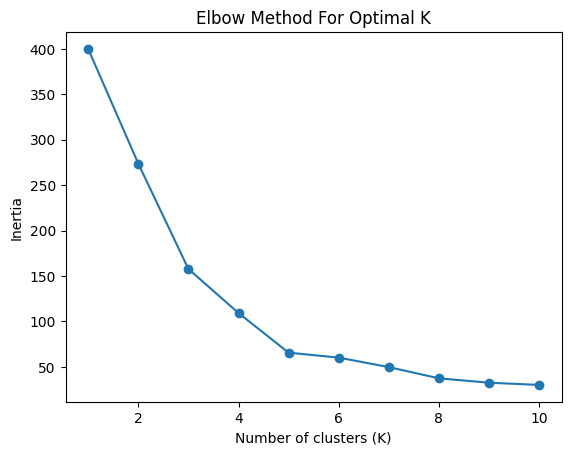

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [11]:
# Initialize KMeans with the chosen K
optimal_k = 5
model = KMeans(n_clusters=optimal_k, random_state=42)

clusters = model.fit_predict(scaled_data)

df['Cluster'] = clusters

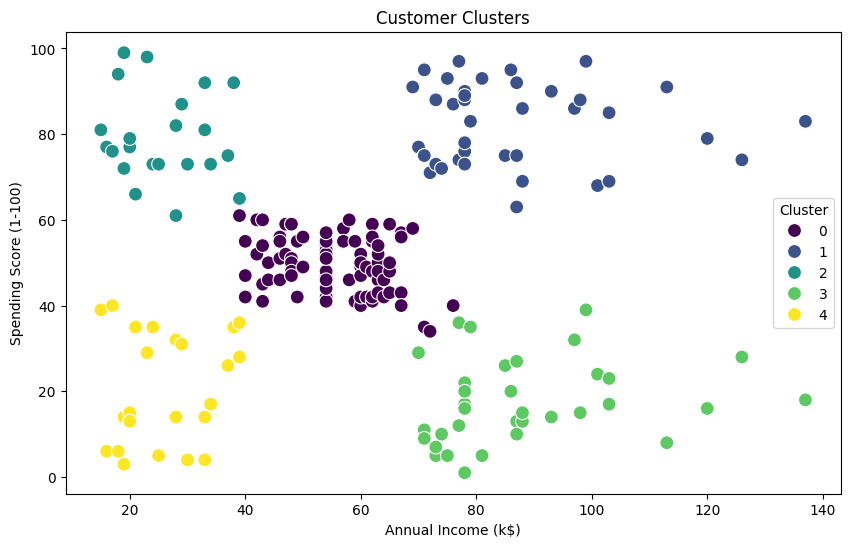

In [12]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'],
                hue=df['Cluster'], palette='viridis', s=100)
plt.title('Customer Clusters')
plt.show()

In [ ]:

Cluster ID,Income,Spending,Customer Type
0,Low,High,"Impulsive Buyers (High spenders, low income)"
1,High,High,"Target Group (High income, high spenders)"
2,Low,Low,Sensible Buyers (Budget-conscious)
3,High,Low,Careful Spenders (Rich but frugal)
4,Average,Average,Standard Customers (The middle ground)


In [13]:
df.to_csv('Segmented_Customers.csv', index=False)

print("File saved successfully!")

File saved successfully!
